# GNN Training - Random Split (Fixed)

**Cambios principales:**
1. Split random estratificado (0% cold-start)
2. Entrenamiento optimizado con mini-batches
3. Grafos construidos directamente en el notebook

In [1]:
# Instalación
!pip install -q torch torchvision torchaudio
!pip install -q torch-geometric
!pip install -q sentence-transformers
!pip install -q scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.3 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, LGConv
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import random
from collections import defaultdict
from sentence_transformers import SentenceTransformer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Device: cuda


## 1. Descargar Datos con Split Random

In [3]:
!mkdir -p data
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2_random/twitter15_processed.csv -O data/twitter15.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2_random/twitter16_processed.csv -O data/twitter16.csv
!wget -q https://raw.githubusercontent.com/aLotOfGluten/IIC3633-Proyecto/refs/heads/main/data_processing/processed_round2/negative_samples.csv -O data/negative_samples.csv

print("✓ Datos descargados")

✓ Datos descargados


## 2. Construir Grafos y Splits

In [4]:
# Cargar datos
df15 = pd.read_csv('data/twitter15.csv', sep=';')
df16 = pd.read_csv('data/twitter16.csv', sep=';')
df = pd.concat([df15, df16], ignore_index=True)

print(f"Total interacciones: {len(df):,}")
print(f"Usuarios: {df['child_user_id'].nunique():,}")
print(f"Items: {df['source_tree_id'].nunique():,}")

# Crear mappings con SOLO train
train_df_full = df[df['split'] == 'train']
unique_users = sorted(train_df_full['child_user_id'].unique())
unique_items = sorted(train_df_full['source_tree_id'].unique())

user_to_idx = {uid: idx for idx, uid in enumerate(unique_users)}
item_to_idx = {iid: idx for idx, iid in enumerate(unique_items)}

# Agregar usuarios de val/test
for user_id in df['child_user_id'].unique():
    if user_id not in user_to_idx:
        user_to_idx[user_id] = len(user_to_idx)

num_users = len(user_to_idx)
num_items = len(item_to_idx)

print(f"\nMapeado: {num_users:,} users, {num_items:,} items")

# Aplicar mappings
df['user_idx'] = df['child_user_id'].map(user_to_idx)
df['item_idx'] = df['source_tree_id'].map(item_to_idx)

# Filtrar val/test (eliminar items no vistos en train)
train_items = set(item_to_idx.keys())
df = df[df['source_tree_id'].isin(train_items)].dropna(subset=['user_idx', 'item_idx'])
df['user_idx'] = df['user_idx'].astype(int)
df['item_idx'] = df['item_idx'].astype(int)

# Crear splits
train_df = df[df['split'] == 'train'][['user_idx', 'item_idx']].reset_index(drop=True)
val_df = df[df['split'] == 'val'][['user_idx', 'item_idx']].reset_index(drop=True)
test_df = df[df['split'] == 'test'][['user_idx', 'item_idx']].reset_index(drop=True)

print(f"\nSplits:")
print(f"  Train: {len(train_df):,}")
print(f"  Val: {len(val_df):,}")
print(f"  Test: {len(test_df):,}")

Total interacciones: 110,732
Usuarios: 39,958
Items: 1,386

Mapeado: 39,958 users, 1,386 items

Splits:
  Train: 88,036
  Val: 10,448
  Test: 12,248


In [5]:
# Construir grafo bipartito (SOLO train)
train_edges = []
for _, row in train_df.iterrows():
    u, i = row['user_idx'], row['item_idx']
    train_edges.append([u, num_users + i])
    train_edges.append([num_users + i, u])

train_edge_index = torch.LongTensor(train_edges).t().contiguous().to(device)

print(f"Grafo bipartito: {train_edge_index.shape}")

Grafo bipartito: torch.Size([2, 176072])


## 3. Negative Sampling

In [6]:
negative_samples = pd.read_csv('data/negative_samples.csv')

user_id_to_idx = {v: k for k, v in enumerate(unique_users)}
item_id_to_idx = item_to_idx.copy()

# Agregar usuarios de val/test al mapping
for user_id in df['child_user_id'].unique():
    if user_id not in user_id_to_idx:
        user_id_to_idx[user_id] = len(user_id_to_idx)

negative_samples['user_idx'] = negative_samples['user_id'].map(user_id_to_idx)
negative_samples['item_idx'] = negative_samples['item_id'].map(item_id_to_idx)
negative_samples = negative_samples.dropna(subset=['user_idx', 'item_idx'])

neg_dict = defaultdict(list)
for _, row in negative_samples.iterrows():
    neg_dict[int(row['user_idx'])].append(int(row['item_idx']))

print(f"Negatives: {len(negative_samples):,} samples, {len(neg_dict):,} users")

Negatives: 382,391 samples, 34,618 users


## 4. Item Embeddings

In [15]:
# BERT embeddings
item_texts = df.groupby('source_tree_id')['text'].first().to_dict()
ordered_texts = []
for item_id in sorted(item_to_idx.keys(), key=lambda x: item_to_idx[x]):
    text = item_texts.get(item_id, "empty tweet")
    if pd.isna(text) or text == "":
        text = "empty tweet"
    ordered_texts.append(text)

print(f"Generando BERT embeddings para {len(ordered_texts)} items...")
model_bert = SentenceTransformer('all-MiniLM-L6-v2')
item_embeddings_bert = model_bert.encode(ordered_texts, show_progress_bar=True, convert_to_tensor=True)
item_embeddings_bert = item_embeddings_bert.clone().detach().to(device)

# Random embeddings
item_embeddings_random = torch.empty(num_items, 64)
nn.init.xavier_uniform_(item_embeddings_random)
item_embeddings_random = item_embeddings_random.to(device)

print(f"BERT: {item_embeddings_bert.shape}, Random: {item_embeddings_random.shape}")

Generando BERT embeddings para 1386 items...


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

BERT: torch.Size([1386, 384]), Random: torch.Size([1386, 64])


## 5. Modelos

In [16]:
class GCNRecommender(nn.Module):
    def __init__(self, num_users, num_items, item_feature_dim, embedding_dim=128, hidden_dim=64):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_projection = nn.Linear(item_feature_dim, embedding_dim)
        self.conv1 = GCNConv(embedding_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, embedding_dim)
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_projection.weight)

    def forward(self, edge_index, item_features):
        user_emb = self.user_embedding.weight
        item_emb = self.item_projection(item_features)
        x = torch.cat([user_emb, item_emb], dim=0)
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        return x[:self.num_users], x[self.num_users:]

class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=128, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.item_embedding.weight)

    def forward(self, edge_index):
        x = torch.cat([self.user_embedding.weight, self.item_embedding.weight], dim=0)
        all_emb = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            all_emb.append(x)
        final = torch.stack(all_emb, dim=0).mean(dim=0)
        return final[:self.num_users], final[self.num_users:]

print("✓ Modelos definidos")

✓ Modelos definidos


## 6. Training Utils (Optimizado)

In [17]:
class InteractionDataset(Dataset):
    def __init__(self, interactions_df, neg_dict, num_items):
        self.users = interactions_df['user_idx'].values
        self.items = interactions_df['item_idx'].values
        self.neg_dict = neg_dict
        self.num_items = num_items

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        user = self.users[idx]
        pos_item = self.items[idx]
        if user in self.neg_dict and len(self.neg_dict[user]) > 0:
            neg_item = np.random.choice(self.neg_dict[user])
        else:
            neg_item = np.random.randint(0, self.num_items)
        return user, pos_item, neg_item

def train_epoch_batched(model, edge_index, item_features, train_loader, optimizer, device, is_lightgcn=False):
    model.train()
    total_loss = 0

    for batch_users, batch_pos, batch_neg in train_loader:
        batch_users = batch_users.to(device)
        batch_pos = batch_pos.to(device)
        batch_neg = batch_neg.to(device)

        optimizer.zero_grad()

        # Forward completo por cada batch
        if is_lightgcn:
            user_emb, item_emb = model(edge_index)
        else:
            user_emb, item_emb = model(edge_index, item_features)

        u_emb = user_emb[batch_users]
        pos_emb = item_emb[batch_pos]
        neg_emb = item_emb[batch_neg]

        pos_scores = (u_emb * pos_emb).sum(dim=1)
        neg_scores = (u_emb * neg_emb).sum(dim=1)

        loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-10).mean()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

print("✓ Training utils definidas")

✓ Training utils definidas


## 7. Evaluación

In [18]:
@torch.no_grad()
def evaluate_model(model, edge_index, item_features, test_df, train_df, k=10, is_lightgcn=False):
    model.eval()
    if is_lightgcn:
        user_emb, item_emb = model(edge_index)
    else:
        user_emb, item_emb = model(edge_index, item_features)

    train_items_per_user = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()

    recommendations = []
    ground_truth = []

    for user_idx in range(model.num_users):
        scores = torch.matmul(user_emb[user_idx], item_emb.t())
        if user_idx in train_items_per_user:
            scores[list(train_items_per_user[user_idx])] = -float('inf')
        _, top = torch.topk(scores, k)
        recommendations.append(top.cpu().tolist())
        ground_truth.append(set(test_df[test_df['user_idx'] == user_idx]['item_idx'].values))

    return recommendations, ground_truth

def compute_metrics(recommendations, ground_truth, num_items):
    rr = []
    for rec, truth in zip(recommendations, ground_truth):
        rank = None
        for i, item in enumerate(rec, 1):
            if item in truth:
                rank = i
                break
        rr.append(1.0 / rank if rank else 0.0)
    mrr = np.mean(rr)

    all_recommended = set()
    for rec in recommendations:
        all_recommended.update(rec)
    coverage = len(all_recommended) / num_items

    return {'MRR': mrr, 'Coverage': coverage}

print("✓ Evaluación lista")

✓ Evaluación lista


## 8. Entrenar GCN-BERT

  0%|          | 0/200 [00:00<?, ?it/s]

Epoch 0: Loss=0.5033
Epoch 10: Loss=0.1640
Epoch 20: Loss=0.1099
Epoch 30: Loss=0.0999
Epoch 40: Loss=0.0934
Epoch 50: Loss=0.0839
Epoch 60: Loss=0.0747
Epoch 70: Loss=0.0724
Epoch 80: Loss=0.0718
Epoch 90: Loss=0.0713
Epoch 100: Loss=0.0653
Epoch 110: Loss=0.0610
Epoch 120: Loss=0.0607
Epoch 130: Loss=0.0579
Epoch 140: Loss=0.0582
Epoch 150: Loss=0.0562
Epoch 160: Loss=0.0529
Epoch 170: Loss=0.0529
Epoch 180: Loss=0.0510
Epoch 190: Loss=0.0527


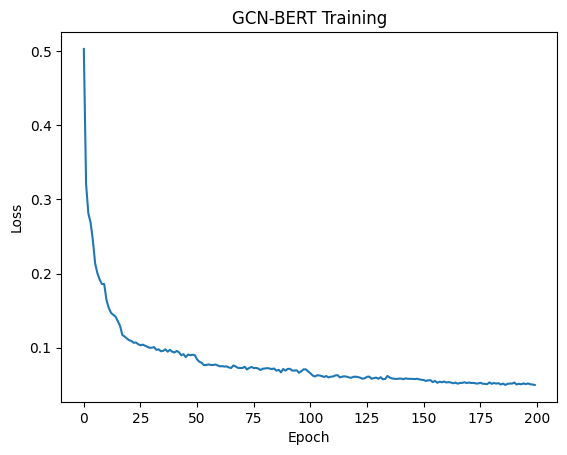


Métricas: {'MRR': np.float64(0.006343952817124647), 'Coverage': 0.5591630591630592}


In [20]:
EPOCHS = 200
BATCH_SIZE = 1024

model = GCNRecommender(num_users, num_items, item_embeddings_bert.shape[1], 128, 64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

dataset = InteractionDataset(train_df, neg_dict, num_items)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

losses = []
for epoch in tqdm(range(EPOCHS)):
    loss = train_epoch_batched(model, train_edge_index, item_embeddings_bert, loader, optimizer, device, False)
    scheduler.step()
    losses.append(loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss={loss:.4f}")

plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GCN-BERT Training')
plt.show()

recs, gt = evaluate_model(model, train_edge_index, item_embeddings_bert, test_df, train_df, 10, False)
metrics = compute_metrics(recs, gt, num_items)
print(f"\nMétricas: {metrics}")